In [1]:
#%matplotlib inline
%time from hikyuu.interactive import *
use_draw_engine('matplotlib')

Initialize hikyuu_2.8.2_202609250345_RELEASE_macosx_arm64 ...
2026-09-25 13:45:31.528 [HKU-I] - current python version: 3.13.12 (main.cpp:77)


2026-09-25 13:45:32,997 [INFO] runing in interactive session [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:149) [hikyuu::hku_info]
2026-09-25 13:45:32,998 [INFO] running in jupyter [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:156) [hikyuu::hku_info]


2026-09-25 13:45:33.002 [HKU-I] - 插件路径: /Users/fasiondog/workspace/hku_plugin/hikyuu_plugin (StockManager.cpp:124)
2026-09-25 13:45:33.033 [HKU-I] - Using CLICKHOUSE BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-09-25 13:45:33.046 [HKU-I] - Mapped hikyuu kdata shm cache: hikyuu_ks_000001a0d717ce65 (epoch: 1790315056741, covered stock entries: 8968) (IpcConnector.cpp:174)
2026-09-25 13:45:33.046 [HKU-I] - Mapped hikyuu base info shm cache: hikyuu_bi_000001a0d7188434 (epoch: 1790315103284, covered stock entries: 12081, finance fields: 584) (IpcConnector.cpp:191)
2026-09-25 13:45:33.046 [HKU-I] - Connected to hikyuu shm server: ipc:///var/folders/5m/v_9j2xl169l9_sqhbbwsxkx40000gn/T//hikyuu_shm_server_3445e4360a34698b.ipc, running in client mode. (StockManager.cpp:288)
2026-09-25 13:45:33.056 [HKU-I] - 加载市场信息…… (StockManager.cpp:1050)
2026-09-25 13:45:33.056 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:1067)
2026-09-25 13:45:33.056 [HKU-I] - 加载证券信息…… (StockManager.cpp:948)
2026-09-25 13:45:33.160 

# 一、策略分析

## 原始描述

建仓条件：expma周线exp1跟exp2金叉向上使用使用 B=50% 的资金买入股票，建仓成功后，卖出条件才能起作用

卖出条件S1：expma日线exp1和exp2死叉向下时卖出持仓股 S=50%

买入条件B1：expma日线exp1和exp2金叉向上时买入股票数为S（卖出条件S1卖出股数）

S1和B1就这样循环

清仓条件为：expma周线exp1和exp2死叉时


## 策略分析

市场环境：无

系统有效性：周线EMA1（快线）和EMA2（慢线）金叉向上直到两者死叉，系统有效时建立初始仓位

信号指示器：
- 买入：日线EMA1（快线）和EMA2（慢线）金叉向上
- 卖出：日线EMA1（快线）和EMA2（慢线）死叉向下

止损/止盈：无

资金管理：
- 初次建仓：使用50%的资金
- 买入：初次建仓时持股数的50%
- 卖出：初次建仓时持股数的50%

盈利目标：无


# 二、实现系统部件

## 自定义系统有效性策略

In [2]:
def getNextWeekDateList(week):
    from datetime import timedelta
    py_week = week.datetime()
    next_week_start = py_week + timedelta(days = 7 - py_week.weekday())
    next_week_end = next_week_start + timedelta(days=5)
    return get_date_range(Datetime(next_week_start), Datetime(next_week_end))
#ds = getNextWeekDateList(Datetime(201801010000))
#for d in ds:
#    print(d)

In [3]:
def DEMO_CN(self):
    """ The system is valid when DIF > DEA
    Parameters:
    fast_n: the weekly DIF window
    slow_n: the weekly DEA window
    """
    k = self.to
    if (len(k) <= 10):
        return
    
    #-----------------------------
    # Weekly line        
    #-----------------------------
    week_q = Query(k[0].datetime, k[-1].datetime, ktype=Query.WEEK)
    week_k = k.get_stock().get_kdata(week_q)
    
    n1 = self.get_param("week_macd_n1")
    n2 = self.get_param("week_macd_n2")
    n3 = self.get_param("week_macd_n3")
    m = MACD(CLOSE(week_k), n1, n2, n3)
    fast = m.get_result(0)
    slow = m.get_result(1)

    x = fast > slow
    for i in range(x.discard, len(x)-1):
        if (x[i] >= 1.0):
            # It needs to be extended to the daily line (must be the next week)
            date_list = getNextWeekDateList(week_k[i].datetime)
            for d in date_list:
                self._add_valid(d)

## 自定义信号指示器

In [4]:
# This example does not need it; the built-in SG_Cross function can be used directly

## 自定义资金管理策略

In [5]:
class DEMO_MM(MoneyManagerBase):
    """
    Initial position: use 50% of the funds
    Buy: 50% of the shares held at the initial position
    Sell: 50% of the shares held at the initial position
    """
    def __init__(self):
        super(DEMO_MM, self).__init__("MACD_MM")
        self.set_param("init_position", 0.5) # Custom initial position parameter, the percentage of the funds occupied
        self.next_buy_num = 0
        
    def _reset(self):
        self.next_buy_num = 0
        #pass
        
    def _clone(self):
        mm = DEMO_MM()
        mm.next_buy_num = self.next_buy_num
        #return DEMO_MM()
    
    def _get_buy_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        cash = tm.current_cash
        
        # If the signal comes from the system valid condition, establish the initial position
        if part_from == System.Part.CONDITION:
            #return int((cash * 0.5 // price // stk.atom) * stk.atom)  # MoneyManagerBase already guarantees that the buy is an integer multiple of the minimum trading quantity
            self.next_buy_num = 0 # Clear the number of the shares bought/sold in a rolling way during the previous position-building period
            return int(cash * self.get_param("init_position") // price)
        
        # Not the initial position, buy the same quantity
        return self.next_buy_num
    
    def _get_sell_num(self, datetime, stk, price, risk, part_from):
        tm = self.tm
        position = tm.get_position(datetime, stk)
        current_num = int(position.number * 0.5)
        
        # Record the number of the shares at the first sell, so as to buy the same quantity next time
        if self.next_buy_num == 0:
            self.next_buy_num = current_num 
            
        return current_num # The return type must be an integer

# 三、构建并运行系统

## 修改设定公共参数

每个系统部件以及TradeManager都有自己的公共参数会影响系统运行，具体可以查看帮助及试验。

比如：这个例子当前使用系统有效条件进行初始建仓，那么必须设置系统公共参数cn_open_position为True。否则，没有建立初始仓位的话，后续没有卖出，不会有任何交易。

In [6]:
# System parameters
# delay=True #(bool): whether to delay the trade to the open of the next bar
# delay_use_current_price=True #(bool): in the case of a delayed operation, whether to calculate the new stop-loss/take-profit/target price with the price of the bar at the current trade or use the result calculated last time
# max_delay_count=3 #(int): the limit on the number of the consecutive delayed trade requests
# tp_monotonic=True #(bool): the take-profit increases monotonically
# tp_delay_n=3 #(int): the number of the days when the take-profit delay starts, i.e. the take-profit strategy takes effect only after several days of the actual trading
# ignore_sell_sg=False #(bool): ignore the sell signal, and sell only by the stop-loss/take-profit and the other ways
# ev_open_position=False #(bool): whether to use the market environment for the initial position building

cn_open_position=True #(bool): whether to use the system valid condition for the initial position building

# MoneyManager common parameters
# auto-checkin=False #(bool): when the account cash is insufficient to buy the quantity indicated by the money management strategy, automatically deposit (checkin) enough cash into the account.
# max-stock=20000 #(int): the maximum number of the kinds of the held securities (i.e. how many stocks are held, not the position size of each stock)
# disable_ev_force_clean_position=False #(bool): disable forcibly clearing the positions when the market environment becomes invalid
# disable_cn_force_clean_position=False #(bool): disable forcibly clearing the positions when the system valid condition becomes invalid


## 设定私有参数及待测试标的

In [7]:
# Account parameters
init_cash = 500000 # Account initial capital
init_date = '1990-1-1' # Account creation date

# Signal generator parameters
week_n1 = 12
week_n2 = 26
week_n3 = 9

# Select the target and the test range
stk = sm['sz000002']

# If it is the same K-line level, the index number can be used; if different K-line levels are used, it is recommended to use the date as the parameter
# Besides, if the data volume is too large, the matplotlib drawing will be slower
start_date = Datetime('2016-01-01')  
end_date = Datetime()

## 构建系统实例

In [8]:
# Create a simulated trading account for backtesting with an initial capital of 300,000
my_tm = crtTM(date=Datetime(init_date), init_cash = init_cash)

# Create the system instance
my_sys = SYS_Simple()

my_sys.set_param("cn_open_position", cn_open_position)

my_sys.tm = my_tm
my_cn = crtCN(DEMO_CN, 
              {'week_macd_n1': week_n1, 'week_macd_n2': week_n2, 'week_macd_n3': week_n3}, 
                'DEMO_CN')  
my_sys.cn = my_cn
my_sys.sg = SG_Cross(EMA(C, n=week_n1), EMA(C, n=week_n2))
my_mm = DEMO_MM()
my_sys.mm = my_mm

## 运行系统

In [9]:
q = Query(start_date, end_date, ktype=Query.DAY)
my_sys.run(stk, q)

# Save the trade records and positions to a temporary directory, which can be viewed with Excel
# The temporary directory is usually set to the tmp subdirectory under the data directory
# If the excel records are open, remember to close the excel file before running the system again; otherwise the new results cannot be saved
my_tm.tocsv(sm.tmpdir())

# 四、查看资金曲线及绩效统计

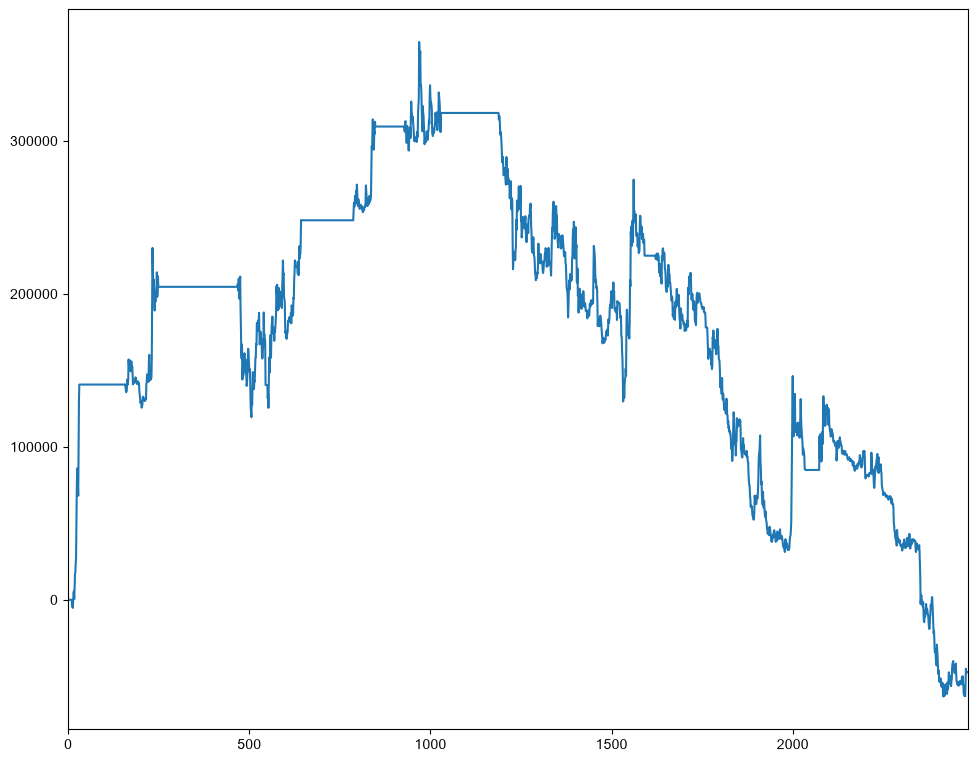

In [10]:
# Draw the equity return curve
x = my_tm.get_profit_curve(stk.get_datetime_list(q), Query.DAY)
#x = my_tm.getFundsCurve(stk.getDatetimeList(q), KQuery.DAY) # Equity net value curve
PRICELIST(x).plot()

In [11]:
# Backtest statistics
per = my_tm.get_performance()
print(per.to_df())

                                    name          value
0                Account Initial Capital  500000.000000
1               Total Invested Principal  500000.000000
2                  Total Invested Assets       0.000000
3                    Total Borrowed Cash       0.000000
4                  Total Borrowed Assets       0.000000
5                        Total Dividends   73016.580000
6                           Cash Balance  452595.030000
7                Open Position Net Value       0.000000
8                   Current Total Assets  452595.030000
9            Total Cost of Closed Trades       0.000000
10     Total Net Profit of Closed Trades  -47404.970000
11            Max Cash Usage per Trade %      49.989836
12            Avg Cash Usage per Trade %      40.437186
13        Open Position Account Return %      -9.480994
14         Closed Trade Account Return %      -9.480994
15                        Account CAGR %      -0.972339
16           Account Avg Annual Return %      -0

# 五、或许想看下图形

<Axes: title={'center': '账户(SYS) 累积收益率'}>

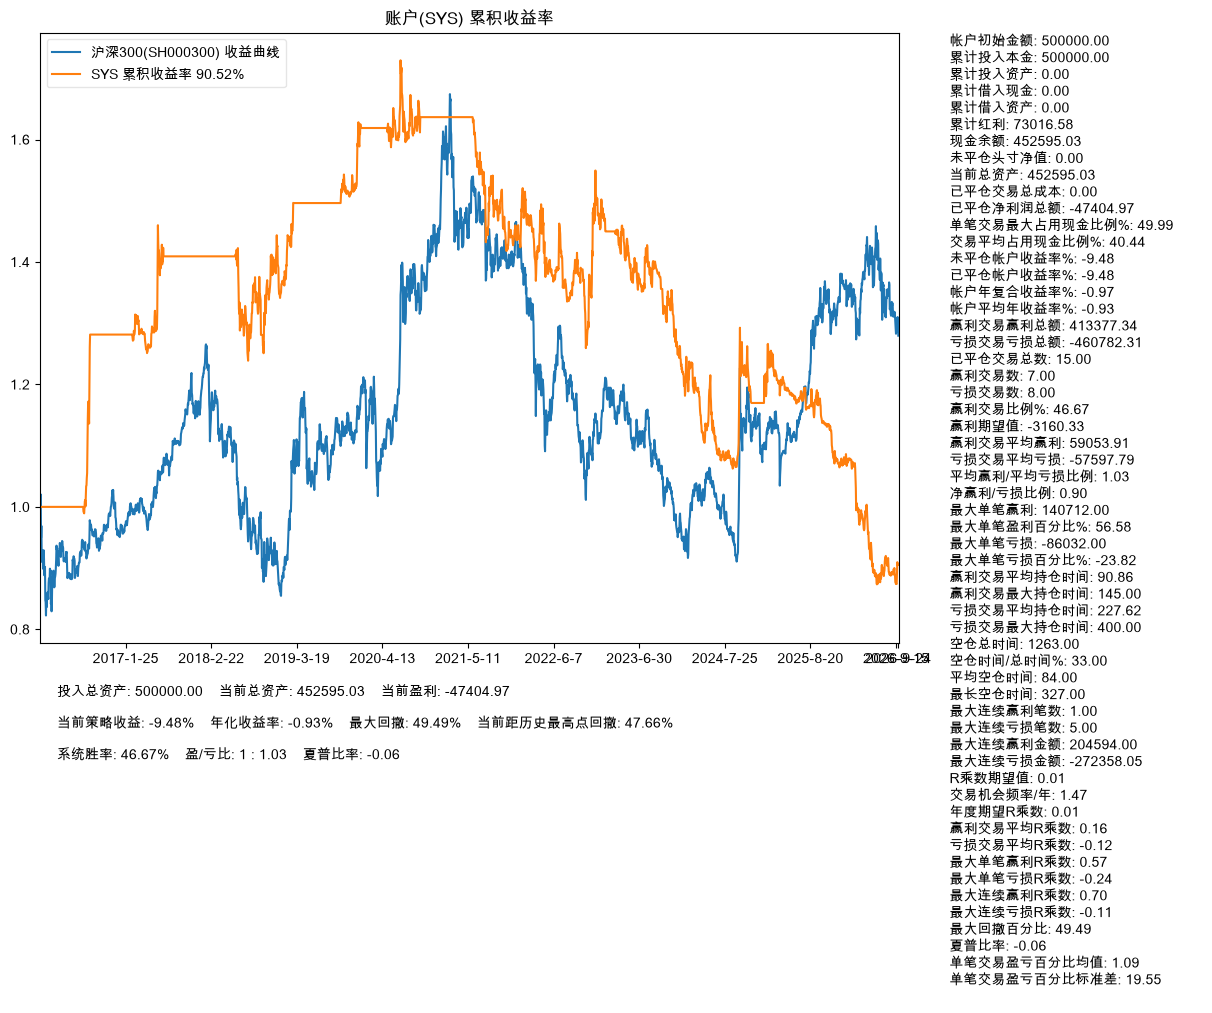

In [12]:
my_sys.performance()

# 六、或许想看看所有股票的情况

In [13]:
import pandas as pd
def calTotal(blk, q):
    per = Performance()
    s_name = []
    s_code = []
    x = []
    for stk in blk:
        my_sys.run(stk, q)
        per.statistics(my_tm, Datetime.now())
        s_name.append(stk.name)
        s_code.append(stk.market_code)
        x.append(per["Current Total Assets"])
    return pd.DataFrame({'code': s_code, 'name': s_name, 'total_assets': x})

%time data = calTotal(blocka, q)

2026-09-25 13:46:47.820 [HKU-E] - 2021-11-12 00:00:00 SH600519 Sell number(50) must be >= minTradeNumber(100)! (TradeManager.cpp:919)
2026-09-25 13:46:47.821 [HKU-E] - 2022-04-27 00:00:00 SH600519 Sell number(50) must be >= minTradeNumber(100)! (TradeManager.cpp:919)
2026-09-25 13:46:47.821 [HKU-E] - 2022-05-19 00:00:00 SH600519 Sell number(50) must be >= minTradeNumber(100)! (TradeManager.cpp:919)
2026-09-25 13:46:47.822 [HKU-E] - 2022-05-25 00:00:00 SH600519 Sell number(50) must be >= minTradeNumber(100)! (TradeManager.cpp:919)
2026-09-25 13:46:47.822 [HKU-E] - 2023-03-08 00:00:00 SH600519 Sell number(50) must be >= minTradeNumber(100)! (TradeManager.cpp:919)
2026-09-25 13:46:47.822 [HKU-E] - 2023-07-11 00:00:00 SH600519 Sell number(50) must be >= minTradeNumber(100)! (TradeManager.cpp:919)
CPU times: user 52.7 s, sys: 1.88 s, total: 54.6 s
Wall time: 3min 26s


In [14]:
# Save to a CSV file
# data.to_csv(sm.tmpdir() + '/statistics.csv')
data[:10]

,code,name,total_assets
0,SZ002465,海格通信,447519.56
1,SZ002380,科远智慧,522242.14
2,SH600208,衢州发展,601481.74
3,SZ000509,华塑控股,471800.50
4,SZ000513,丽珠集团,592177.86
5,SH603683,晶华新材,615872.26
6,SZ002509,天茂退,500000.00
7,SZ002657,中科金财,336068.47
8,SH600237,铜峰电子,630514.83
9,SZ002532,天山铝业,521719.46
